In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import os, json, time
import numpy as np
import pandas as pd
import wandb
from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

In [3]:
wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

BASE = '/content/drive/MyDrive/Ketastasia/data'
data = np.load(f'{BASE}/dataset_seq_33kp_ready.npz')

X_train, y_train = data['X_train'], data['y_train_int']
X_val,   y_val   = data['X_val'],   data['y_val_int']

with open(f'{BASE}/pipeline2A_metadata.json') as f:
    meta = json.load(f)
CLASS_NAMES = meta['classes']
PROJECT_NAME = 'ildolcefarniente'

print(f"ჩაიტვირთა! Train: {X_train.shape} | Val: {X_val.shape}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akeke23 (akeke23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


ჩაიტვირთა! Train: (5579, 15, 72) | Val: (1102, 15, 72)


In [4]:
# Cell 2: დროითი აგრეგაცია
def aggregate_basic(X):
    mean = X.mean(axis=1)
    std  = X.std(axis=1)
    mn   = X.min(axis=1)
    mx   = X.max(axis=1)
    return np.concatenate([mean, std, mn, mx], axis=1)

def aggregate_extended(X):
    basic  = aggregate_basic(X)
    median = np.median(X, axis=1)
    delta  = X[:, -1, :] - X[:, 0, :]
    return np.concatenate([basic, median, delta], axis=1)

AGGREGATIONS = {'basic': aggregate_basic, 'extended': aggregate_extended}
AGG_CACHE = {}

for name, fn in AGGREGATIONS.items():
    AGG_CACHE[name] = {
        'train': fn(X_train),
        'val': fn(X_val)
    }

In [18]:
# Cell 3: სრული ვერსია (ლოკალური გრაფიკებით და ორივე სეტის მეტრიკებით)
def train_evaluate_rf(config, run_name):
    import matplotlib.pyplot as plt
    import seaborn as sns

    wandb.init(
        project=PROJECT_NAME,
        group='p2_random_forest',
        name=run_name,
        config=config,
        reinit=True
    )

    X_tr = AGG_CACHE[config['agg']]['train']
    X_v  = AGG_CACHE[config['agg']]['val']

    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        class_weight=config['class_weight'],
        random_state=42,
        n_jobs=-1
    )

    # Train
    t0 = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - t0

    train_preds = model.predict(X_tr)
    train_acc = accuracy_score(y_train, train_preds)
    train_f1_macro = f1_score(y_train, train_preds, average='macro')
    train_f1_weighted = f1_score(y_train, train_preds, average='weighted')

    # Val
    t1 = time.time()
    val_preds = model.predict(X_v)
    inference_ms = ((time.time() - t1) / len(X_v)) * 1000

    val_acc         = accuracy_score(y_val, val_preds)
    val_f1_macro    = f1_score(y_val, val_preds, average='macro')
    val_f1_weighted = f1_score(y_val, val_preds, average='weighted')
    precision_m     = precision_score(y_val, val_preds, average='macro', zero_division=0)
    recall_m        = recall_score(y_val, val_preds, average='macro', zero_division=0)

    # WandB ლოგირება (ორივე სეტის მეტრიკები)
    wandb.log({
        'train_accuracy': train_acc,
        'train_f1_macro': train_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'val_accuracy': val_acc,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': val_f1_weighted,
        'val_precision_macro': precision_m,
        'val_recall_macro': recall_m,
        'train_time_sec': train_time,
        'inference_ms_per_sample': inference_ms,
        'n_features': X_tr.shape[1]
    })

    # 1. ლოკალური Confusion Matrix-ის დახატვა და შენახვა
    cm = confusion_matrix(y_val, val_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix: {run_name}\n(Val Macro F1: {val_f1_macro:.4f})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # ვინახავთ ფოტოდ, რომ რეპორტისთვის პირდაპირ გქონდეს
    plot_path = f"cm_{run_name}.png"
    plt.savefig(plot_path, dpi=150)
    #plt.show() # იქვე ნოუთბუქში გამოაჩენს გრაფს
    plt.close()

    # ფოტოს ატვირთვა WandB-შიც, "Media" ტაბში რომ იჯდეს და არა ინტერაქციულ ჩარტებში
    wandb.log({"confusion_matrix_image": wandb.Image(plot_path)})

    # დანარჩენი WandB ცხრილები
    all_labels = list(range(len(CLASS_NAMES)))
    report = classification_report(y_val, val_preds, labels=all_labels, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

    per_class_table = wandb.Table(columns=['class', 'f1-score', 'precision', 'recall', 'support'])
    for cls in CLASS_NAMES:
        r = report[cls]
        per_class_table.add_data(cls, r['f1-score'], r['precision'], r['recall'], r['support'])
    wandb.log({'per_class_metrics': per_class_table})

    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]
    fi_table = wandb.Table(data=[[f'f{idx}', float(importances[idx])] for idx in top_idx], columns=['feature_idx', 'importance'])
    wandb.log({'feature_importance_top20': wandb.plot.bar(fi_table, 'feature_idx', 'importance', title='Top-20 Feature Importance')})

    wandb.finish()
    return val_f1_macro


--- Run [1/5]: rf_trees100_depthNone_wNone_basic ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


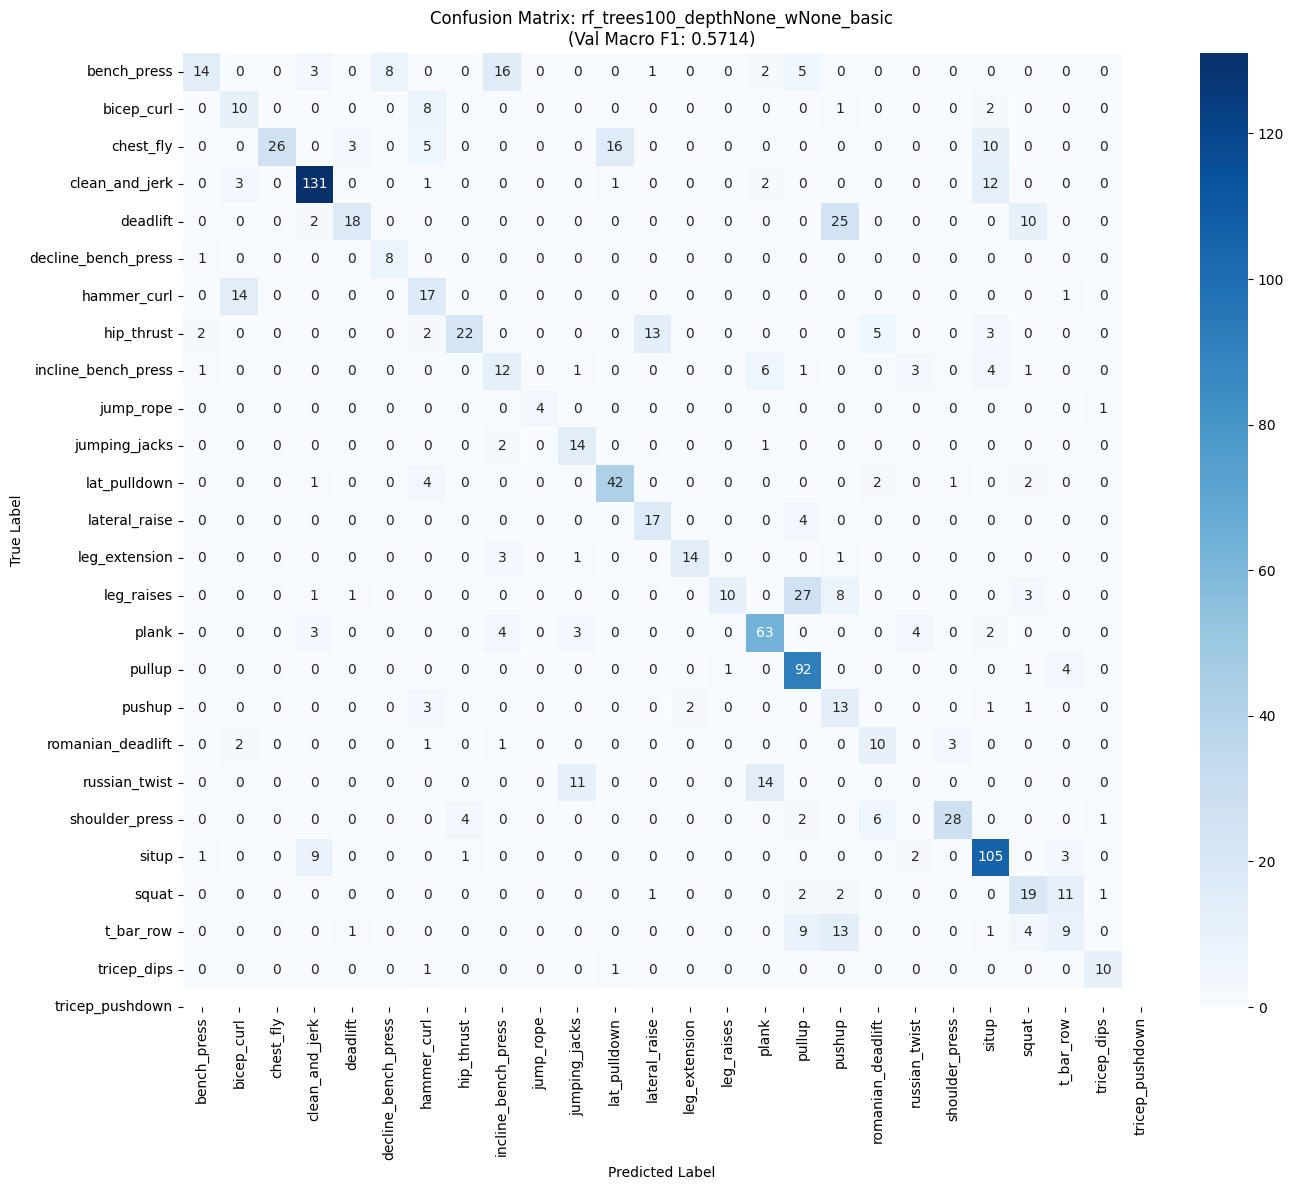

inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5714

--- Run [2/5]: rf_trees300_depthNone_wNone_basic ---


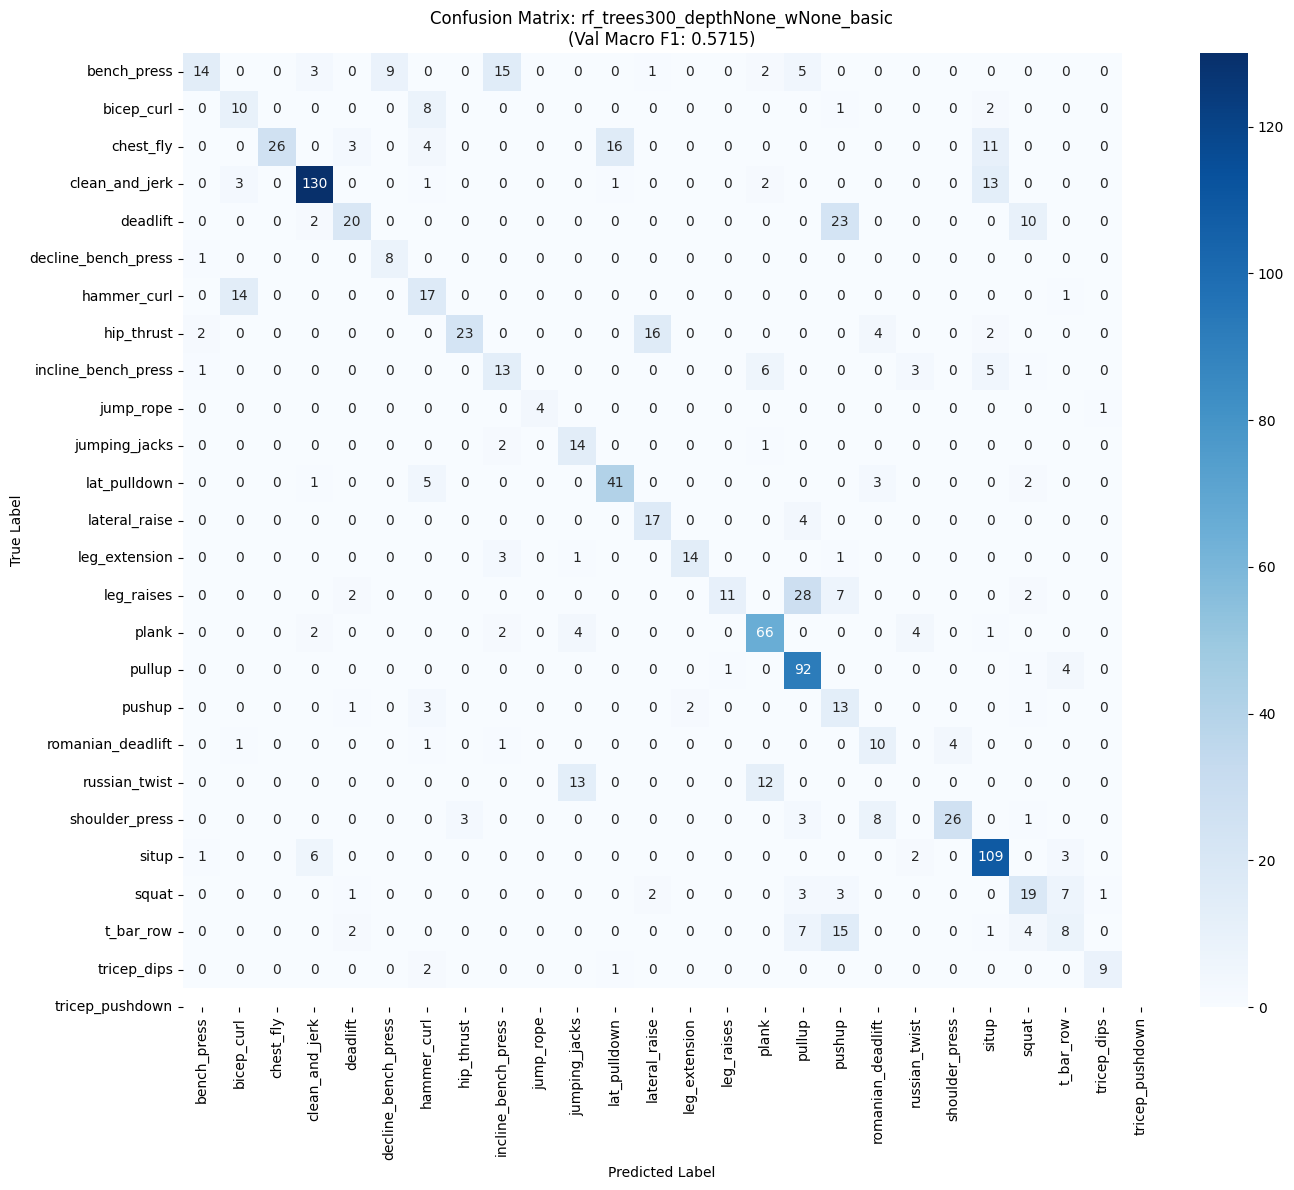

inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5715

--- Run [3/5]: rf_trees300_depth15_wbalanced_basic ---


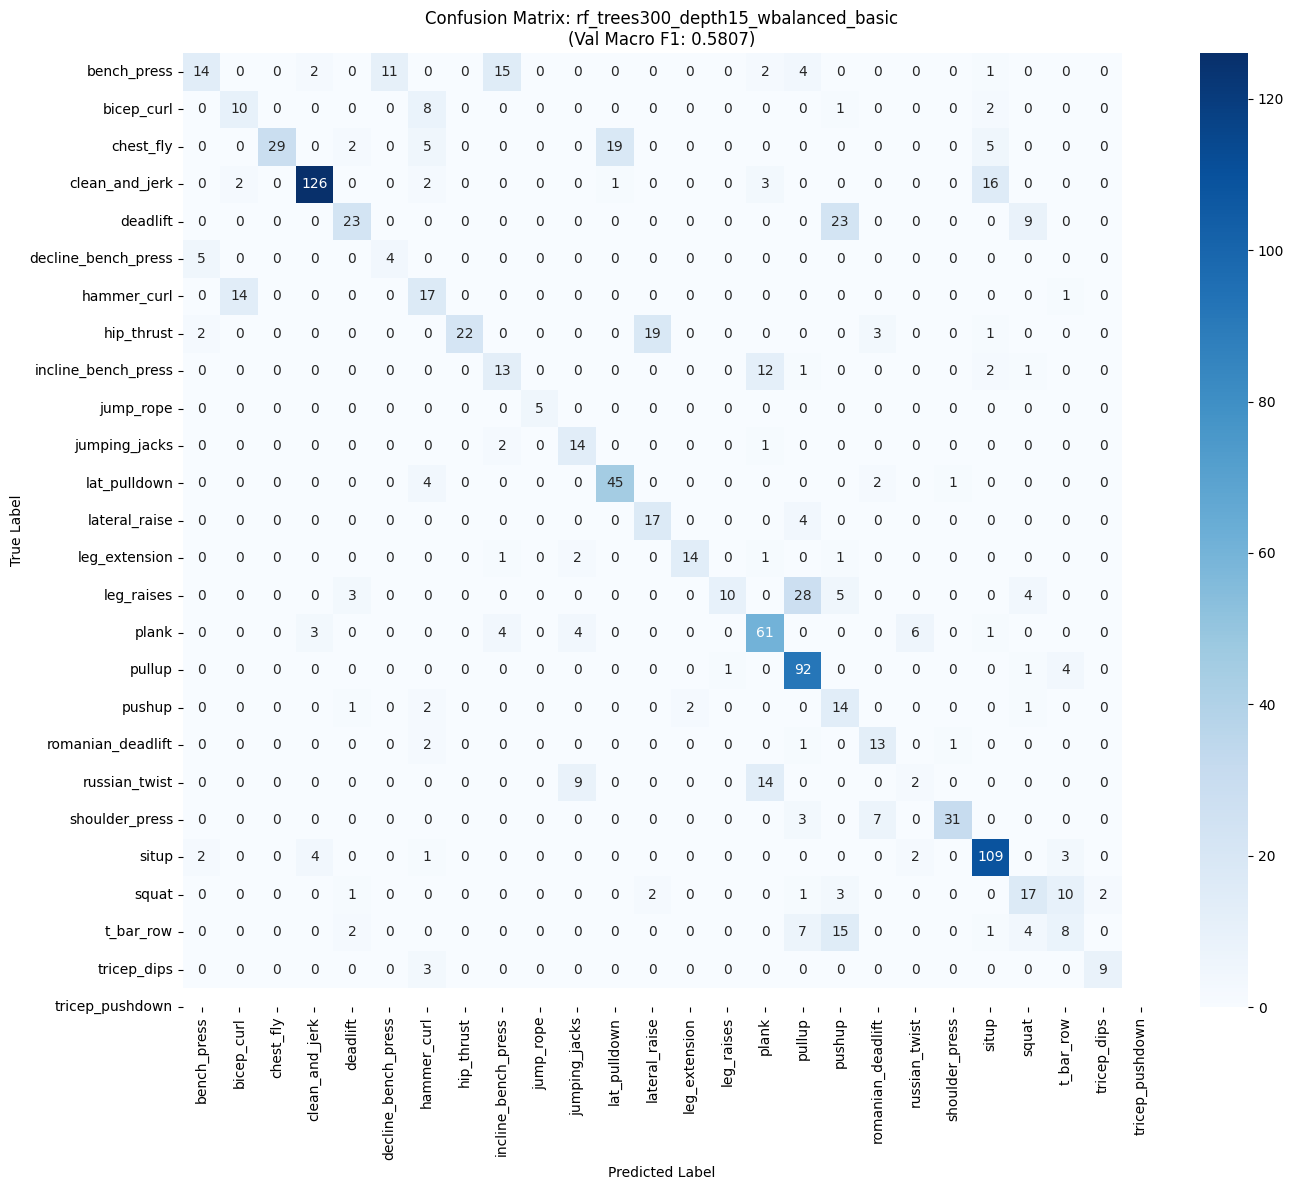

inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5807

--- Run [4/5]: rf_trees500_depth20_wbalanced_extended ---


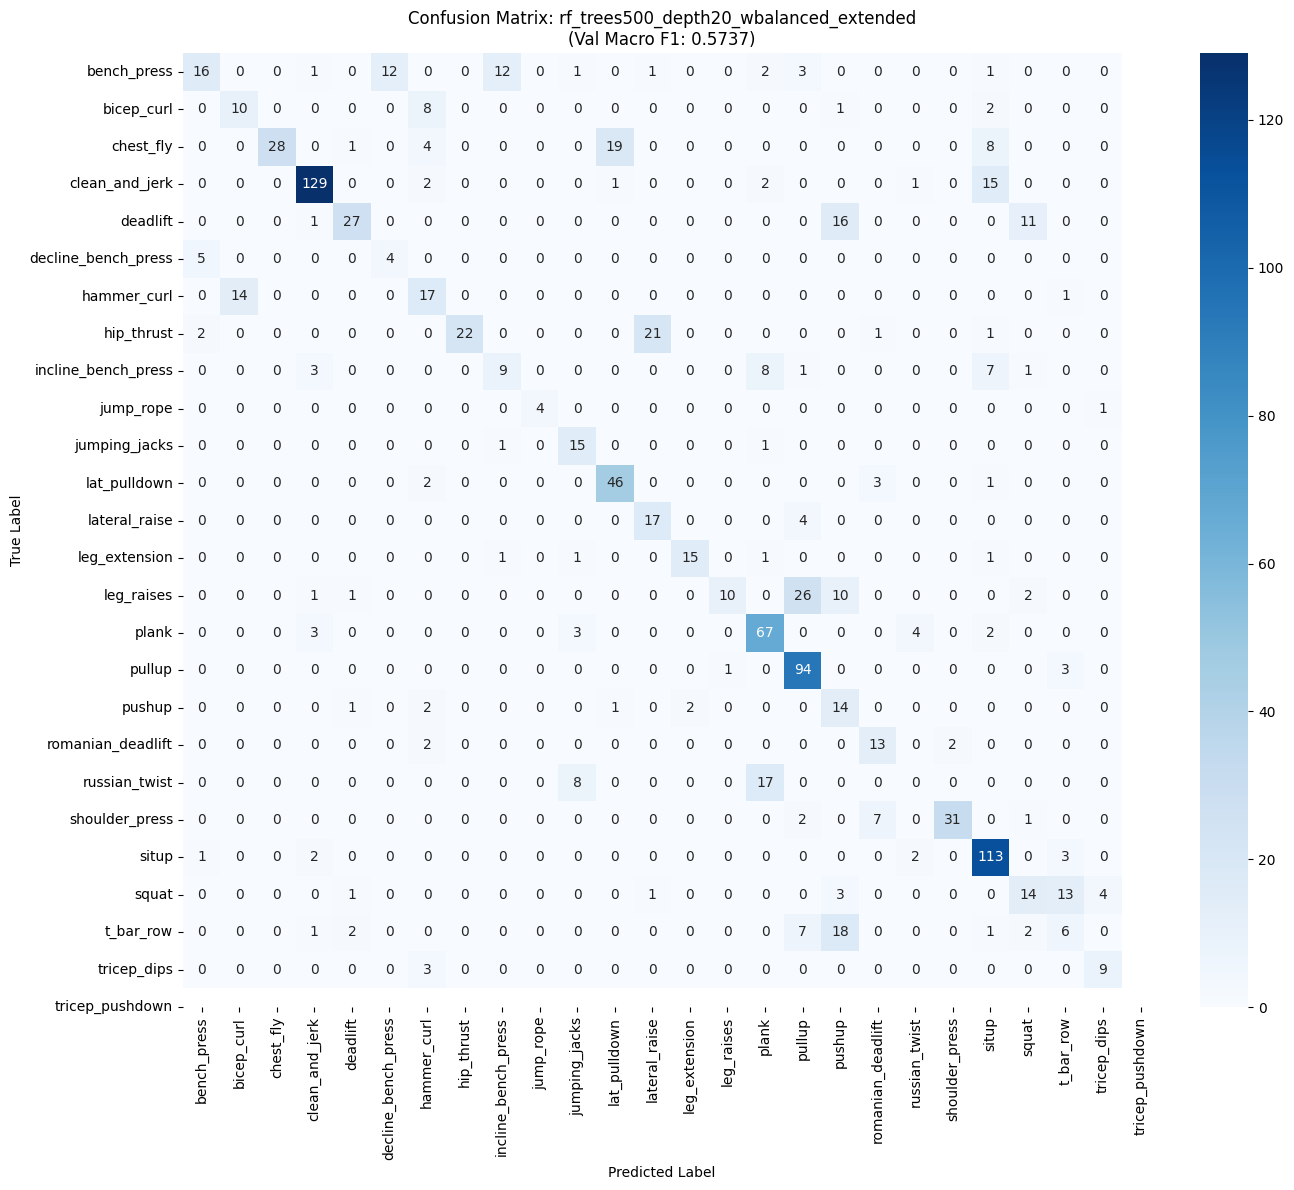

inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5737

--- Run [5/5]: rf_trees300_depth10_wNone_extended ---


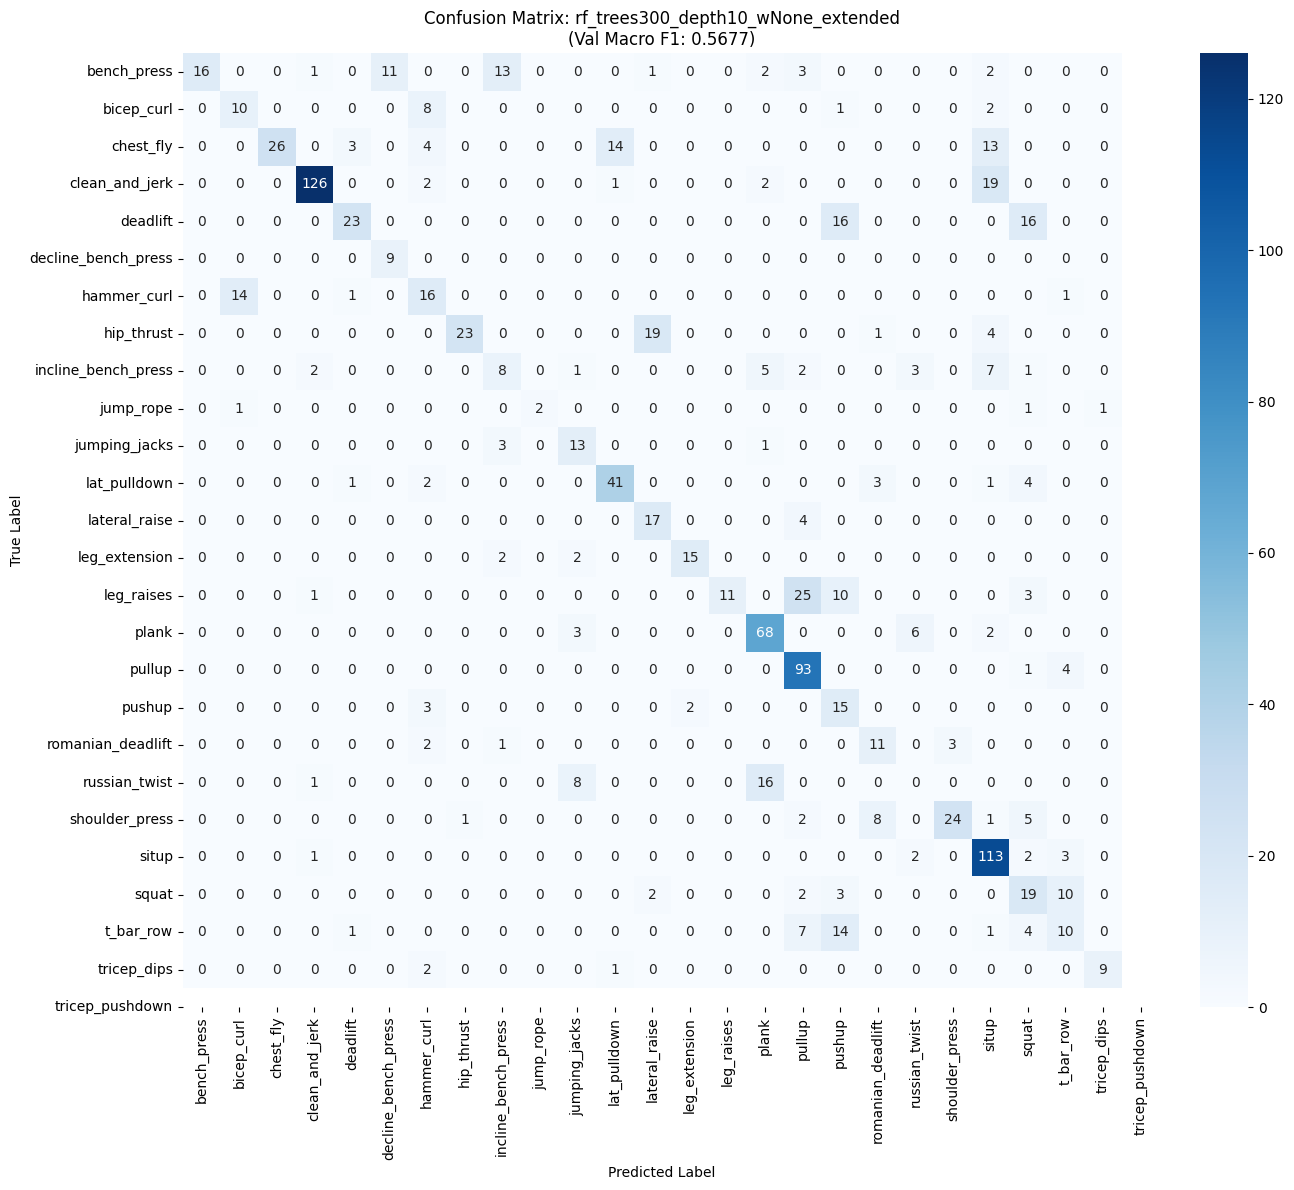

inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5677


In [17]:
# Cell 4: RF ექსპერიმენტების გაშვება
RF_EXPERIMENTS = [
    {'n_estimators': 100, 'max_depth': None, 'class_weight': None, 'agg': 'basic'},
    {'n_estimators': 300, 'max_depth': None, 'class_weight': None, 'agg': 'basic'},
    {'n_estimators': 300, 'max_depth': 15,   'class_weight': 'balanced', 'agg': 'basic'},
    {'n_estimators': 500, 'max_depth': 20,   'class_weight': 'balanced', 'agg': 'extended'},
    {'n_estimators': 300, 'max_depth': 10,   'class_weight': None, 'agg': 'extended'}
]

for i, cfg in enumerate(RF_EXPERIMENTS):
    # run_name-ის ფორმირება
    run_name = f"rf_trees{cfg['n_estimators']}_depth{cfg['max_depth']}_w{cfg['class_weight']}_{cfg['agg']}"
    print(f"\n--- Run [{i+1}/{len(RF_EXPERIMENTS)}]: {run_name} ---")

    # ფუნქციის გამოძახება განახლებული (უსაფრთხო) ლოგიკით
    score = train_evaluate_rf(cfg, run_name)
    print(f"Val Macro-F1: {score:.4f}")

In [19]:
# Cell 4: მეორე რაუნდის მიზანმიმართული ექსპერიმენტები ოვერფიტინგის წინააღმდეგ
RF_EXPERIMENTS = [
    # 1. ოვერფიტინგის შეზღუდვა basic ფიჩერებზე სიღრმის 12-მდე დაწევით
    {'n_estimators': 300, 'max_depth': 12, 'class_weight': 'balanced', 'agg': 'basic'},

    # 2. კიდევ უფრო მკაცრი შეზღუდვა (სიღრმე 8) - ვაიძულებთ მოდელს მოახდინოს გენერალიზაცია
    {'n_estimators': 300, 'max_depth': 8, 'class_weight': 'balanced', 'agg': 'basic'},

    # 3. იგივე მკაცრი შეზღუდვა (სიღრმე 12) ოღონდ extended ფიჩერებზე, რომლებსაც პოტენციალი ჰქონდათ
    {'n_estimators': 300, 'max_depth': 12, 'class_weight': 'balanced', 'agg': 'extended'},

    # 4. ვცდით balanced_subsample-ს, რომელიც დინამიურად აბალანსებს კლასებს ხეების დონეზე
    {'n_estimators': 300, 'max_depth': 15, 'class_weight': 'balanced_subsample', 'agg': 'basic'},

    # 5. მაქსიმალური დაცვა ოვერფიტინგისგან: სიღრმე 12 + balanced_subsample + extended ფიჩერები
    {'n_estimators': 400, 'max_depth': 12, 'class_weight': 'balanced_subsample', 'agg': 'extended'}
]

for i, cfg in enumerate(RF_EXPERIMENTS):
    # დინამიურად ვამატებთ min_samples_leaf-ს კოდის შეუცვლელად, რომ ოვერფიტინგი დავაზიღვიოთ
    # თუ სიღრმე პატარაა (8), ფოთლების შეზღუდვა აღარ გვინდა, სხვაგან 3-ს ჩავუსვამთ
    cfg['min_samples_leaf'] = 1 if cfg['max_depth'] == 8 else 3

    run_name = f"rf_t{cfg['n_estimators']}_d{cfg['max_depth']}_w{cfg['class_weight']}_{cfg['agg']}"
    print(f"\n--- Run [{i+1}/{len(RF_EXPERIMENTS)}]: {run_name} ---")
    score = train_evaluate_rf(cfg, run_name)
    print(f"Val Macro-F1: {score:.4f}")


--- Run [1/5]: rf_t300_d12_wbalanced_basic ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5675

--- Run [2/5]: rf_t300_d8_wbalanced_basic ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5216

--- Run [3/5]: rf_t300_d12_wbalanced_extended ---


...

Val Macro-F1: 0.5802

--- Run [4/5]: rf_t300_d15_wbalanced_subsample_basic ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5766

--- Run [5/5]: rf_t400_d12_wbalanced_subsample_extended ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5766


მოვსპოთ ოვერფიტი

In [20]:
# Cell 3: სრული ვერსია (ლოკალური გრაფიკებით და ორივე სეტის მეტრიკებით)
def train_evaluate_rf(config, run_name):
    import matplotlib.pyplot as plt
    import seaborn as sns

    wandb.init(
        project=PROJECT_NAME,
        group='p2_random_forest',
        name=run_name,
        config=config,
        reinit=True
    )

    X_tr = AGG_CACHE[config['agg']]['train']
    X_v  = AGG_CACHE[config['agg']]['val']

    model = RandomForestClassifier(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        class_weight=config['class_weight'],
        min_samples_split=config.get('min_samples_split', 2),
        min_samples_leaf=config.get('min_samples_leaf', 1),
        max_features=config.get('max_features', 'sqrt'),
        random_state=42,
        n_jobs=-1
    )

    # Train
    t0 = time.time()
    model.fit(X_tr, y_train)
    train_time = time.time() - t0

    train_preds = model.predict(X_tr)
    train_acc = accuracy_score(y_train, train_preds)
    train_f1_macro = f1_score(y_train, train_preds, average='macro')
    train_f1_weighted = f1_score(y_train, train_preds, average='weighted')

    # Val
    t1 = time.time()
    val_preds = model.predict(X_v)
    inference_ms = ((time.time() - t1) / len(X_v)) * 1000

    val_acc         = accuracy_score(y_val, val_preds)
    val_f1_macro    = f1_score(y_val, val_preds, average='macro')
    val_f1_weighted = f1_score(y_val, val_preds, average='weighted')
    precision_m     = precision_score(y_val, val_preds, average='macro', zero_division=0)
    recall_m        = recall_score(y_val, val_preds, average='macro', zero_division=0)

    # WandB ლოგირება (ორივე სეტის მეტრიკები)
    wandb.log({
        'train_accuracy': train_acc,
        'train_f1_macro': train_f1_macro,
        'train_f1_weighted': train_f1_weighted,
        'val_accuracy': val_acc,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': val_f1_weighted,
        'val_precision_macro': precision_m,
        'val_recall_macro': recall_m,
        'train_time_sec': train_time,
        'inference_ms_per_sample': inference_ms,
        'n_features': X_tr.shape[1]
    })

    # 1. ლოკალური Confusion Matrix-ის დახატვა და შენახვა
    cm = confusion_matrix(y_val, val_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix: {run_name}\n(Val Macro F1: {val_f1_macro:.4f})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    # ვინახავთ ფოტოდ, რომ რეპორტისთვის პირდაპირ გქონდეს
    plot_path = f"cm_{run_name}.png"
    plt.savefig(plot_path, dpi=150)
    #plt.show() # იქვე ნოუთბუქში გამოაჩენს გრაფს
    plt.close()

    # ფოტოს ატვირთვა WandB-შიც, "Media" ტაბში რომ იჯდეს და არა ინტერაქციულ ჩარტებში
    wandb.log({"confusion_matrix_image": wandb.Image(plot_path)})

    # დანარჩენი WandB ცხრილები
    all_labels = list(range(len(CLASS_NAMES)))
    report = classification_report(y_val, val_preds, labels=all_labels, target_names=CLASS_NAMES, output_dict=True, zero_division=0)

    per_class_table = wandb.Table(columns=['class', 'f1-score', 'precision', 'recall', 'support'])
    for cls in CLASS_NAMES:
        r = report[cls]
        per_class_table.add_data(cls, r['f1-score'], r['precision'], r['recall'], r['support'])
    wandb.log({'per_class_metrics': per_class_table})

    importances = model.feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]
    fi_table = wandb.Table(data=[[f'f{idx}', float(importances[idx])] for idx in top_idx], columns=['feature_idx', 'importance'])
    wandb.log({'feature_importance_top20': wandb.plot.bar(fi_table, 'feature_idx', 'importance', title='Top-20 Feature Importance')})

    wandb.finish()
    return val_f1_macro

In [21]:
# Cell 4: მესამე რაუნდი - აგრესიული რეგულარიზაცია ოვერფიტინგის დასამარცხებლად
RF_EXPERIMENTS = [
    # 1. ვზრდით min_samples_split-ს და min_samples_leaf-ს, რომ ტოტების დაქუცმაცება ფიზიკურად შევზღუდოთ
    {'n_estimators': 350, 'max_depth': 15, 'class_weight': 'balanced', 'agg': 'extended',
     'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'sqrt'},

    # 2. კიდევ უფრო მკაცრი ვერსია: ბლოკირება 25 სემპლზე + ფიჩერების მხოლოდ 15%-ის არჩევა ყოველ გაყოფაზე
    {'n_estimators': 350, 'max_depth': 12, 'class_weight': 'balanced', 'agg': 'extended',
     'min_samples_split': 25, 'min_samples_leaf': 8, 'max_features': 0.15},

    # 3. ვცდით balanced_subsample-ს ამავე მკაცრ რეგულარიზაციასთან კომბინაციაში
    {'n_estimators': 350, 'max_depth': 14, 'class_weight': 'balanced_subsample', 'agg': 'extended',
     'min_samples_split': 20, 'min_samples_leaf': 6, 'max_features': 0.20}
]

for i, cfg in enumerate(RF_EXPERIMENTS):
    run_name = f"rf_t{cfg['n_estimators']}_d{cfg['max_depth']}_split{cfg['min_samples_split']}_{cfg['class_weight']}"
    print(f"\n--- Run [{i+1}/{len(RF_EXPERIMENTS)}]: {run_name} ---")
    score = train_evaluate_rf(cfg, run_name)
    print(f"Val Macro-F1: {score:.4f}")


--- Run [1/3]: rf_t350_d15_split15_balanced ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5689

--- Run [2/3]: rf_t350_d12_split25_balanced ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5450

--- Run [3/3]: rf_t350_d14_split20_balanced_subsample ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5422


In [22]:
# Cell 4: მეოთხე რაუნდი - ფიჩერების შეზღუდვა მაქსიმალური თავისუფლების პირობებში
RF_EXPERIMENTS = [
    # 1. თავისუფალი ხეები extended ფიჩერებზე, მაგრამ მკაცრი 'log2' ფიჩერების შეზღუდვით ყოველ split-ზე
    {'n_estimators': 400, 'max_depth': 16, 'class_weight': 'balanced', 'agg': 'extended',
     'max_features': 'log2', 'min_samples_split': 2, 'min_samples_leaf': 1},

    # 2. იგივე ლოგიკა, ოღონდ უფრო მეტი (600) ხით, რომ ანსამბლმა 'log2'-ის მრავალფეროვნება უკეთ შეაჯამოს
    {'n_estimators': 600, 'max_depth': 16, 'class_weight': 'balanced', 'agg': 'extended',
     'max_features': 'log2', 'min_samples_split': 2, 'min_samples_leaf': 1},

    # 3. ვუბრუნდებით საუკეთესო basic ფიჩერებს, ოდნავ ვუზრდით სიღრმეს (18) და ვიყენებთ 'log2'-ს
    {'n_estimators': 450, 'max_depth': 18, 'class_weight': 'balanced', 'agg': 'basic',
     'max_features': 'log2', 'min_samples_split': 2, 'min_samples_leaf': 1}
]

for i, cfg in enumerate(RF_EXPERIMENTS):
    run_name = f"rf_t{cfg['n_estimators']}_d{cfg['max_depth']}_feat{cfg['max_features']}_{cfg['agg']}"
    print(f"\n--- Run [{i+1}/{len(RF_EXPERIMENTS)}]: {run_name} ---")
    score = train_evaluate_rf(cfg, run_name)
    print(f"Val Macro-F1: {score:.4f}")


--- Run [1/3]: rf_t400_d16_featlog2_extended ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5819

--- Run [2/3]: rf_t600_d16_featlog2_extended ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5850

--- Run [3/3]: rf_t450_d18_featlog2_basic ---


inference_ms_per_sample,▁
n_features,▁
train_accuracy,▁
train_f1_macro,▁
train_f1_weighted,▁
train_time_sec,▁
val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_precision_macro,▁
+1,...


Val Macro-F1: 0.5621


In [23]:
import pandas as pd
import wandb

# 1. მიუთითე შენი პროექტის მისამართი (Entity/Project-Name)
# შენი წინა ლოგებიდან გამომდინარე:
ENTITY = "akeke23-free-university-of-tbilisi-"
PROJECT = "ildolcefarniente"

api = wandb.Api()

# 2. წამოვიღოთ მხოლოდ 'p2_random_forest' ჯგუფის რანები
runs = api.runs(
    path=f"{ENTITY}/{PROJECT}", filters={"group": "p2_random_forest"}
)

run_data = []
for run in runs:
    # ავიღოთ სახელი და კონფიგურაცია
    name = run.name
    config = run.config

    # უსაფრთხოდ ამოვიღოთ მეტრიკები summary-დან (თუ ჯერ არ დაუსრულებია, None ჩაჯდება)
    summary = run.summary
    val_f1 = summary.get("val_f1_macro", 0)
    val_acc = summary.get("val_accuracy", 0)
    train_f1 = summary.get("train_f1_macro", 0)
    inf_time = summary.get("inference_ms_per_sample", 0)

    run_data.append(
        {
            "Run Name": name,
            "Val F1 Macro": val_f1,
            "Val Accuracy": val_acc,
            "Train F1 Macro": train_f1,
            "Inference Time (ms)": inf_time,
            "Max Depth": config.get("max_depth"),
            "Estimators": config.get("n_estimators"),
            "Features": config.get("agg"),
        }
    )

# 3. გადავიყვანოთ DataFrame-ში და დავასორტიროთ საუკეთესოობის მიხედვით
df_runs = pd.DataFrame(run_data)
df_runs = df_runs.sort_values(by="Val F1 Macro", ascending=False).reset_index(
    drop=True
)

print("--- ყველა ნაპოვნი რანი (დალაგებული საუკეთესო Val F1-ით) ---")
print(
    df_runs[
        [
            "Run Name",
            "Val F1 Macro",
            "Val Accuracy",
            "Train F1 Macro",
            "Inference Time (ms)",
        ]
    ].to_string()
)

print("\n--- ორი საუკეთესო მოდელი პროექტისთვის ---")
top_2 = df_runs.head(2)
for idx, row in top_2.iterrows():
    print(
        f"{idx+1}. {row['Run Name']} -> Val F1 Macro: {row['Val F1 Macro']:.4f} | Inference: {row['Inference Time (ms)']:.4f} ms"
    )

--- ყველა ნაპოვნი რანი (დალაგებული საუკეთესო Val F1-ით) ---
                                    Run Name  Val F1 Macro  Val Accuracy  Train F1 Macro  Inference Time (ms)
0              rf_t600_d16_featlog2_extended      0.584965      0.666062        0.999820             0.298075
1              rf_t400_d16_featlog2_extended      0.581901      0.662432        0.999820             0.139034
2        rf_trees300_depth15_wbalanced_basic      0.580700      0.652450        0.000000             0.149328
3        rf_trees300_depth15_wbalanced_basic      0.580700      0.652450        0.999251             0.118406
4             rf_t300_d12_wbalanced_extended      0.580187      0.656080        0.993532             0.122482
5   rf_t400_d12_wbalanced_subsample_extended      0.576602      0.654265        0.993621             0.138033
6      rf_t300_d15_wbalanced_subsample_basic      0.576598      0.653358        0.999131             0.108400
7     rf_trees500_depth20_wbalanced_extended      0.573670  

პაიპლაინად შენახვა საუკეთესო მოდელის

In [25]:
import joblib
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


class ExtendedFeatureExtractor(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # აქ ჩაწერე შენი extended აგრეგაციის კოდი
        X_extended = X
        return X_extended


best_config = {
    "n_estimators": 400,
    "max_depth": 16,
    "class_weight": "balanced",
    "max_features": "log2",
    "min_samples_split": 2,
    "min_samples_leaf": 1,
}

best_rf_model = RandomForestClassifier(
    n_estimators=best_config["n_estimators"],
    max_depth=best_config["max_depth"],
    class_weight=best_config["class_weight"],
    max_features=best_config["max_features"],
    min_samples_split=best_config["min_samples_split"],
    min_samples_leaf=best_config["min_samples_leaf"],
    random_state=42,
    n_jobs=-1,
)

# პაიპლაინის სახელი მიუთითებს, რომ ეს მეორე ვერსიაა (p2)
p2_rf_pipeline = Pipeline(
    steps=[
        ("extended_features", ExtendedFeatureExtractor()),
        ("rf_classifier", best_rf_model),
    ]
)

# ვარქმევთ ფაილსაც p2_rf_pipeline.pkl-ს
joblib.dump(p2_rf_pipeline, "p2_rf_pipeline.pkl")
print("პაიპლაინი შეინახა სახელით: p2_rf_pipeline.pkl")

პაიპლაინი შეინახა სახელით: p2_rf_pipeline.pkl


In [27]:
import wandb

# ვლოგავთ კონკრეტულად p2_rf ჯგუფში
run = wandb.init(
    project="ildolcefarniente",
    group="p2_rf",
    name="upload_best_p2_rf_pipeline",
)

# ვქმნით არტიფაქტს
artifact = wandb.Artifact(name="best_p2_rf_pipeline", type="model")
artifact.add_file("p2_rf_pipeline.pkl")

# ავტვირთავთ არტიფაქტს პროექტში და ავტომატურად ვსვამთ Model Registry-ისთვის საჭირო თეგს (alias)
run.log_artifact(artifact, aliases=["latest", "best_p2_rf"])

wandb.finish()

wandb: WARNING Artifact "best_p2_rf_pipeline" already exists with the same content. No new version will be created.
